In [ ]:
from pathlib import Path

from plots.wandb_utils import get_wandb_stats

ids = ["8ixofvbl", "rkx580eu"]


histories = []
for id in ids:
    summary, history, config = get_wandb_stats(
        id,
        skip_cache=False,
        wandb_run_cache_path=Path("/mnt/labstore/bespoke_olap/wandb_cache"),
    )
    histories.append(history)

Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/8a6f970a86f22a33da825081d4fb51a85aa922798104abc457ae30b19eb63943.pkl
✓ Run loaded: tpch_initial1-22v11_wstorage
  State: finished
  Created: 2026-03-03T13:45:00Z
✓ Data fetched: 962 turns, 139 columns
✓ W&B data cached to: /mnt/labstore/bespoke_olap/wandb_cache/b8625064623a9db1c917badfdfb9b865b64c6a5888d0720d70abfe85490a53bb.pkl


In [ ]:
assert len(histories) == 2

assert len(histories[0]) == len(histories[1]), (
    f"Lengths differ: {len(histories[0])} vs {len(histories[1])}"
)

# annotate per step runtime to history
for hist in histories:
    hist["step_runtime"] = hist["total_runtime"].diff()

base_hist = histories[0]

base_hist["other_rt"] = histories[1]["step_runtime"]
base_hist["rt_diff"] = base_hist["step_runtime"] - base_hist["other_rt"]

<Axes: >

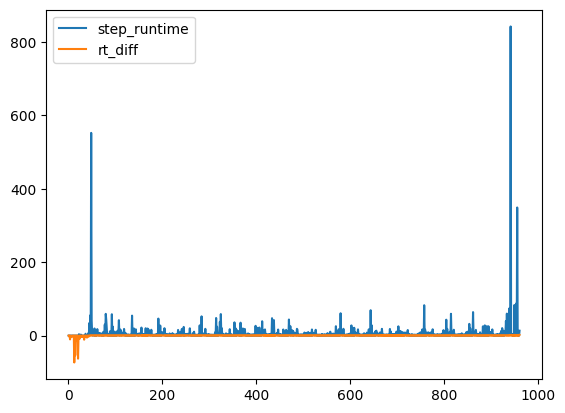

In [ ]:
base_hist[["step_runtime", "rt_diff"]].plot()

In [ ]:
# list top 10 steps with largest runtime difference
base_hist["abs_rt_diff"] = base_hist["rt_diff"].abs()


base_hist[base_hist["_step"] > 500].sort_values("abs_rt_diff", ascending=False).head(
    10
)[["step_runtime", "other_rt", "rt_diff", "type"]]

,step_runtime,other_rt,rt_diff,type
943,3.946308,1.937232,2.009076,llm_call
957,11.557681,9.564052,1.993629,llm_call
952,13.039115,11.078020,1.961096,llm_call
959,7.374620,5.449772,1.924848,llm_call
961,13.402212,11.487282,1.914930,llm_call
950,83.358613,81.447585,1.911028,llm_call
944,3.838905,1.937674,1.901232,llm_call
948,4.071858,2.171220,1.900638,llm_call
946,3.786617,1.893884,1.892732,llm_call
955,3.764471,1.954302,1.810169,llm_call


In [19]:
base_hist

,validation/query_013/impl_runtime_ms,reasoning_tokens,cached_tokens,final/total_cost_usd,validation/external_call,validation/query_021/speedup,final/num_prompts,validation/total_speedup,validation/query_014/duckdb_runtime_ms,cost_usd,...,validation/query_015/speedup,validation/num_successful_queries,validation/fasttest_optimize,tool/llmcall_count,validation/query_001/duckdb_runtime_ms,step_runtime,rt_dff,rt_diff,abs_rt_diff,other_rt
0,NaN,0.0,0.0,NaN,None,NaN,NaN,NaN,NaN,0.003148,...,NaN,NaN,None,1,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,1,NaN,0.040846,0.000738,0.000738,0.000738,0.040108
2,NaN,0.0,0.0,NaN,None,NaN,NaN,NaN,NaN,0.004653,...,NaN,NaN,None,2,NaN,0.137309,-0.013143,-0.013143,0.013143,0.150452
3,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,2,NaN,0.213831,0.000788,0.000788,0.000788,0.213043
4,NaN,0.0,0.0,NaN,None,NaN,NaN,NaN,NaN,0.016163,...,NaN,NaN,None,3,NaN,0.140748,-0.013022,-0.013022,0.013022,0.153770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
957,NaN,448.0,20096.0,NaN,None,NaN,NaN,NaN,NaN,0.015614,...,NaN,NaN,None,490,NaN,11.557681,11.210485,11.210485,11.210485,0.347197
958,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,490,NaN,0.044936,0.003075,0.003075,0.003075,0.041861
959,NaN,256.0,20096.0,NaN,None,NaN,NaN,NaN,NaN,0.014209,...,NaN,NaN,None,491,NaN,7.374620,7.217540,7.217540,7.217540,0.157080
960,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,491,NaN,0.044444,0.002742,0.002742,0.002742,0.041701
